In [1]:
from pathlib import Path

import torch

from rtnls_enface.utils.plotting import plot_gridfns
from rtnls_models.inference import KeypointsEnsemble, SegmentationEnsemble  # noqa: F401
from rtnls_models.utils.config import load_config  # noqa: F401

## Segmentation of preprocessed images

Here we segment images preprocessed using 0_preprocess.ipynb

In [2]:
ds_path = Path("../../samples/fundus")

# input folder. point to a folder with png and/or dicom images
rgb_path = ds_path / "preprocessed_rgb"
ce_path = ds_path / "preprocessed_ce"

# these are the output folders:
av_path = ds_path / "av"
vessels_path = ds_path / "vessels"
overlays_path = ds_path / "overlays"
discs_path = ds_path / "discs"

device = torch.device("cuda:1")

### Artery-vein segmentation

In [3]:
vessels_ensemble = SegmentationEnsemble.from_release("vessels_march_v2").to(device)
vessels_ensemble.predict(ds_path / "rgb", dest_path=vessels_path, num_workers=2)

Filters: [32, 64, 96, 128, 192, 256, 384, 512],
Kernels: [[3, 3], [3, 3], [3, 3], [3, 3], [3, 3], [3, 3], [3, 3], [3, 3]]
Strides: [[1, 1], [2, 2], [2, 2], [2, 2], [2, 2], [2, 2], [2, 2], [2, 2]]
Filters: [32, 64, 96, 128, 192, 256, 384, 512],
Kernels: [[3, 3], [3, 3], [3, 3], [3, 3], [3, 3], [3, 3], [3, 3], [3, 3]]
Strides: [[1, 1], [2, 2], [2, 2], [2, 2], [2, 2], [2, 2], [2, 2], [2, 2]]
Filters: [32, 64, 96, 128, 192, 256, 384, 512],
Kernels: [[3, 3], [3, 3], [3, 3], [3, 3], [3, 3], [3, 3], [3, 3], [3, 3]]
Strides: [[1, 1], [2, 2], [2, 2], [2, 2], [2, 2], [2, 2], [2, 2], [2, 2]]
Filters: [32, 64, 96, 128, 192, 256, 384, 512],
Kernels: [[3, 3], [3, 3], [3, 3], [3, 3], [3, 3], [3, 3], [3, 3], [3, 3]]
Strides: [[1, 1], [2, 2], [2, 2], [2, 2], [2, 2], [2, 2], [2, 2], [2, 2]]
Filters: [32, 64, 96, 128, 192, 256, 384, 512],
Kernels: [[3, 3], [3, 3], [3, 3], [3, 3], [3, 3], [3, 3], [3, 3], [3, 3]]
Strides: [[1, 1], [2, 2], [2, 2], [2, 2], [2, 2], [2, 2], [2, 2], [2, 2]]
{'contrast_enhance':

100%|██████████| 1/1 [00:27<00:00, 27.83s/it]


In [5]:
av_ensemble = SegmentationEnsemble.from_release("av_march_v2").to(device)
# run the model, pass the path for the outputs
av_ensemble.predict_preprocessed(rgb_path, ce_path, dest_path=av_path, num_workers=2)

Filters: [32, 64, 96, 128, 192, 256, 384, 512],
Kernels: [[3, 3], [3, 3], [3, 3], [3, 3], [3, 3], [3, 3], [3, 3], [3, 3]]
Strides: [[1, 1], [2, 2], [2, 2], [2, 2], [2, 2], [2, 2], [2, 2], [2, 2]]
Filters: [32, 64, 96, 128, 192, 256, 384, 512],
Kernels: [[3, 3], [3, 3], [3, 3], [3, 3], [3, 3], [3, 3], [3, 3], [3, 3]]
Strides: [[1, 1], [2, 2], [2, 2], [2, 2], [2, 2], [2, 2], [2, 2], [2, 2]]
Filters: [32, 64, 96, 128, 192, 256, 384, 512],
Kernels: [[3, 3], [3, 3], [3, 3], [3, 3], [3, 3], [3, 3], [3, 3], [3, 3]]
Strides: [[1, 1], [2, 2], [2, 2], [2, 2], [2, 2], [2, 2], [2, 2], [2, 2]]
Filters: [32, 64, 96, 128, 192, 256, 384, 512],
Kernels: [[3, 3], [3, 3], [3, 3], [3, 3], [3, 3], [3, 3], [3, 3], [3, 3]]
Strides: [[1, 1], [2, 2], [2, 2], [2, 2], [2, 2], [2, 2], [2, 2], [2, 2]]
Filters: [32, 64, 96, 128, 192, 256, 384, 512],
Kernels: [[3, 3], [3, 3], [3, 3], [3, 3], [3, 3], [3, 3], [3, 3], [3, 3]]
Strides: [[1, 1], [2, 2], [2, 2], [2, 2], [2, 2], [2, 2], [2, 2], [2, 2]]
{'contrast_enhance':

100%|██████████| 1/1 [00:18<00:00, 18.25s/it]


### Disc segmentation

In [6]:
disc_ensemble = SegmentationEnsemble.from_release("disc").to(device)
disc_ensemble.predict_preprocessed(
    rgb_path, ce_path, dest_path=discs_path, num_workers=2
)

Filters: [32, 64, 96, 128, 192, 256, 384, 512],
Kernels: [[3, 3], [3, 3], [3, 3], [3, 3], [3, 3], [3, 3], [3, 3], [3, 3]]
Strides: [[1, 1], [2, 2], [2, 2], [2, 2], [2, 2], [2, 2], [2, 2], [2, 2]]
Filters: [32, 64, 96, 128, 192, 256, 384, 512],
Kernels: [[3, 3], [3, 3], [3, 3], [3, 3], [3, 3], [3, 3], [3, 3], [3, 3]]
Strides: [[1, 1], [2, 2], [2, 2], [2, 2], [2, 2], [2, 2], [2, 2], [2, 2]]
Filters: [32, 64, 96, 128, 192, 256, 384, 512],
Kernels: [[3, 3], [3, 3], [3, 3], [3, 3], [3, 3], [3, 3], [3, 3], [3, 3]]
Strides: [[1, 1], [2, 2], [2, 2], [2, 2], [2, 2], [2, 2], [2, 2], [2, 2]]
Filters: [32, 64, 96, 128, 192, 256, 384, 512],
Kernels: [[3, 3], [3, 3], [3, 3], [3, 3], [3, 3], [3, 3], [3, 3], [3, 3]]
Strides: [[1, 1], [2, 2], [2, 2], [2, 2], [2, 2], [2, 2], [2, 2], [2, 2]]
Filters: [32, 64, 96, 128, 192, 256, 384, 512],
Kernels: [[3, 3], [3, 3], [3, 3], [3, 3], [3, 3], [3, 3], [3, 3], [3, 3]]
Strides: [[1, 1], [2, 2], [2, 2], [2, 2], [2, 2], [2, 2], [2, 2], [2, 2]]
{'contrast_enhance':

100%|██████████| 1/1 [00:03<00:00,  3.30s/it]


### Fovea detection

In [7]:
fovea_ensemble = KeypointsEnsemble.from_release("fovea_v1").to(device)
# note: this model does not use contrast enhanced images
df = fovea_ensemble.predict_preprocessed(rgb_path, dest_path=discs_path, num_workers=2)
df.columns = ["mean_x", "mean_y"]
df.to_csv(ds_path / "fovea.csv")

{'contrast_enhance': False, 'resize': 512, 'square_size': 1024, 'preprocess': False}
SegmentationDataModule created with len(imgs) = 10, len(lbls) = 0
0 training, 0 validation, 10 test examples
FundusDataset created. len(images_or_paths) = 10, len(masks_or_paths)=0


100%|██████████| 1/1 [00:01<00:00,  1.57s/it]


### Plotting the retinas

This will only work if you ran all the models and stored the outputs using the same folder/file names as above

In [8]:
from vascx.utils.loader import RetinaLoader

loader = RetinaLoader.from_folder(ds_path, fundus_subfolder="preprocessed_rgb")

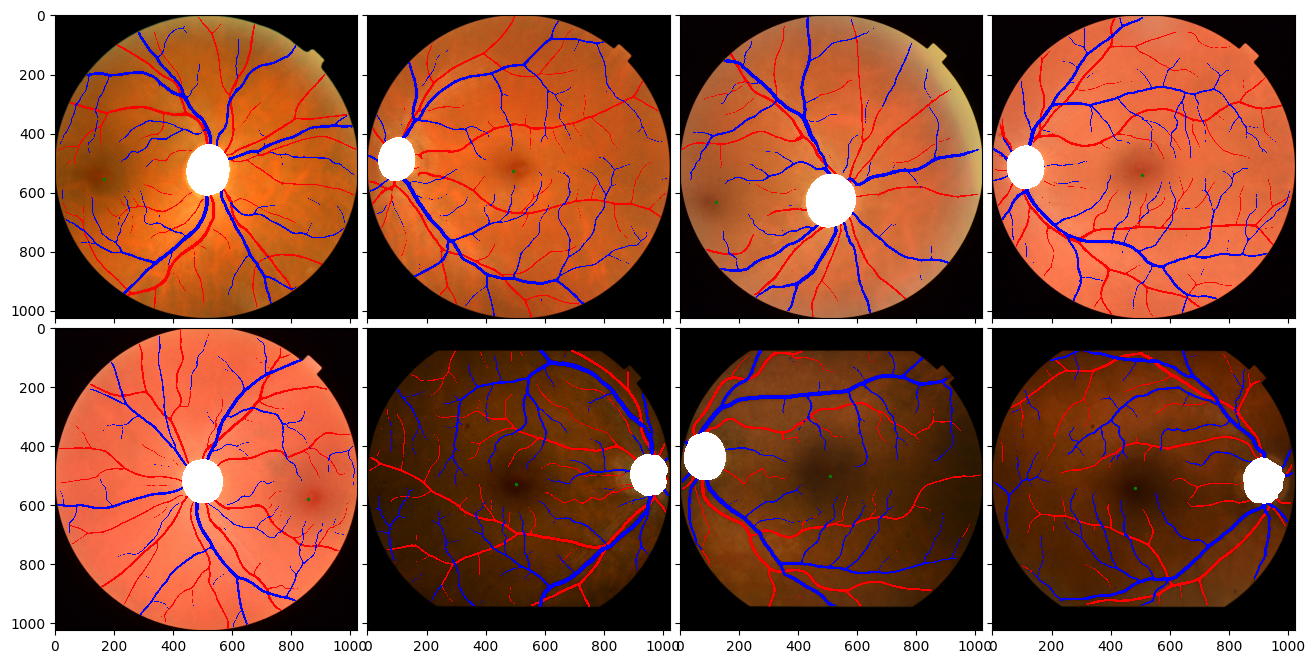

In [9]:
plot_gridfns([ret.plot for ret in loader[:8]])